# Time Series in Environmental Data Analysis: A non-exhaustive cookbook
***

In this exercise, we'll work with the [Mauna Load pCO2 dataset](https://gml.noaa.gov/ccgg/trends/) to consider key aspects of time series analysis in environmental data.

## 1. Load the Data

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
data_url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv'
dat = pd.read_csv(data_url, comment='#', header=None)
# dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)  # if working offline, use local file
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']

In [20]:
# use this to consider different subsets of the data

# for example, just the last 10 years:
# subset = dat[dat['year'] >= (dat['year'].max() - 10)]

# for now, we'll use the full dataset
subset = dat

Text(0.5, 0, 'Year')

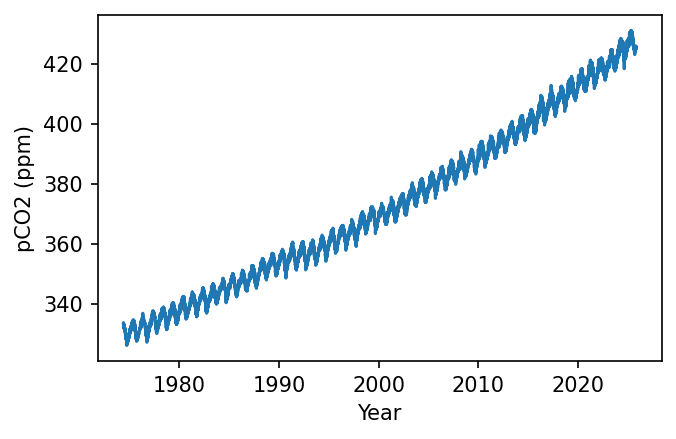

In [21]:
fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')

## 2. Decomposition of time Series
***

Environmental time series are often comprised of four key components: trend, seasonal, cyclical, and irregular (or noise) components. A common first step is to *decompose* the time series to get a better understanding of these underlying patterns.

### Seasonal Trend decomposition using LOESS (STL)
STL is a method used to decompose a time series into three main components: trend, seasonal, and residual. This technique is particularly useful in environmental data analysis, where understanding underlying patterns is crucial for accurate forecasting and decision-making.

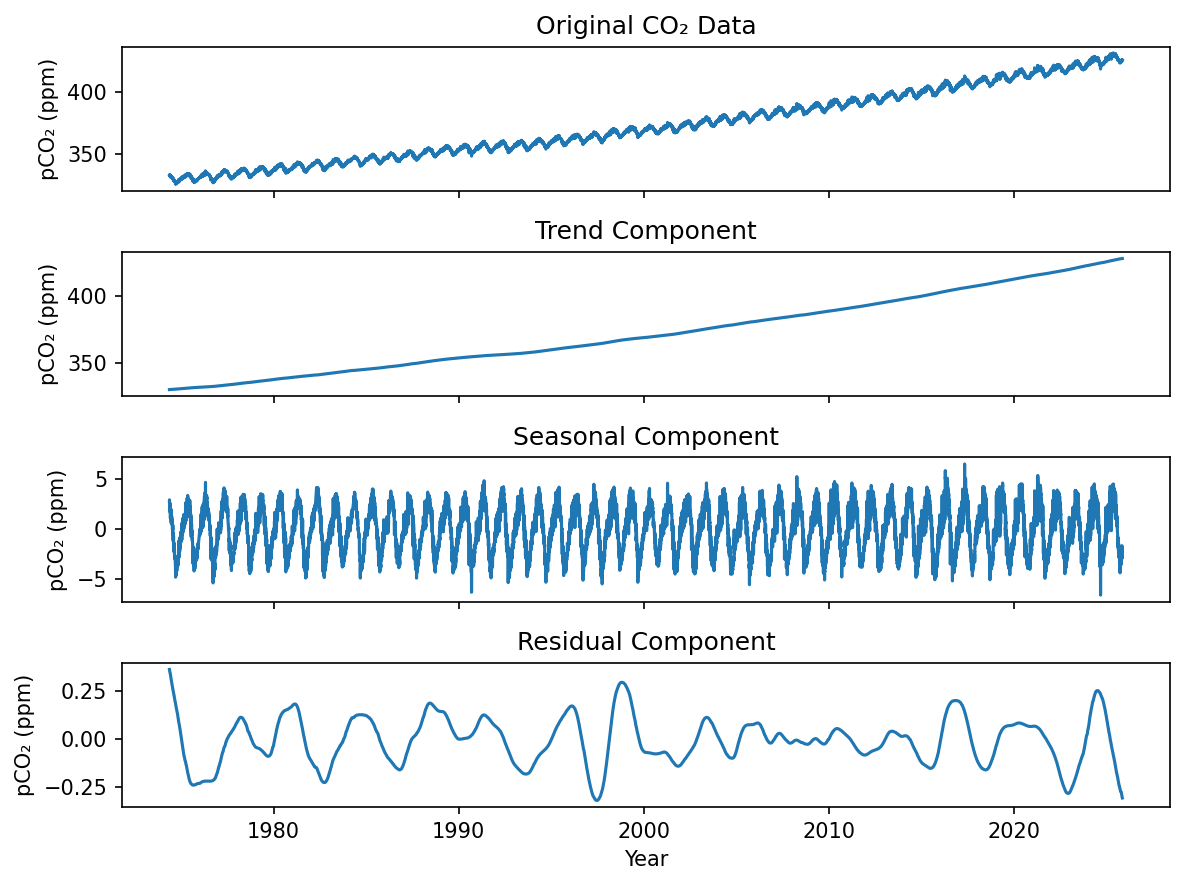

In [24]:
from statsmodels.tsa.seasonal import STL

# STL decomposition - need to set frequency for seasonal period
# For daily data with annual cycle, use freq=365
# seasonal=X controls smoothing, larger = smoother.

stl = STL(subset['pCO2'], seasonal=3, period=365)  
result = stl.fit()

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

# Original data
axes[0].plot(subset['decimal_date'], subset['pCO2'])
axes[0].set_title('Original CO₂ Data')
axes[0].set_ylabel('pCO₂ (ppm)')

# Trend component
axes[1].plot(subset['decimal_date'], result.trend)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('pCO₂ (ppm)')

# Seasonal component
axes[2].plot(subset['decimal_date'], result.seasonal)
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('pCO₂ (ppm)')

# Residual component
axes[3].plot(subset['decimal_date'], result.resid)
axes[3].set_title('Residual Component')
axes[3].set_ylabel('pCO₂ (ppm)')
axes[3].set_xlabel('Year')

plt.tight_layout()
plt.show()

### Identifying Periodicities with Spectrograms

A spectrogram is a visual representation of the spectrum of frequencies in a signal as it varies with time. It is particularly useful for analysing non-stationary signals, where frequency content changes over time. In environmental data analysis, spectrograms can help identify periodic patterns, trends, and anomalies in time series data.

Another related tool is a periodogram, which estimates the power spectral density of a signal. While a periodogram provides a global view of frequency content, a spectrogram offers a time-resolved perspective, making it more suitable for non-stationary data.

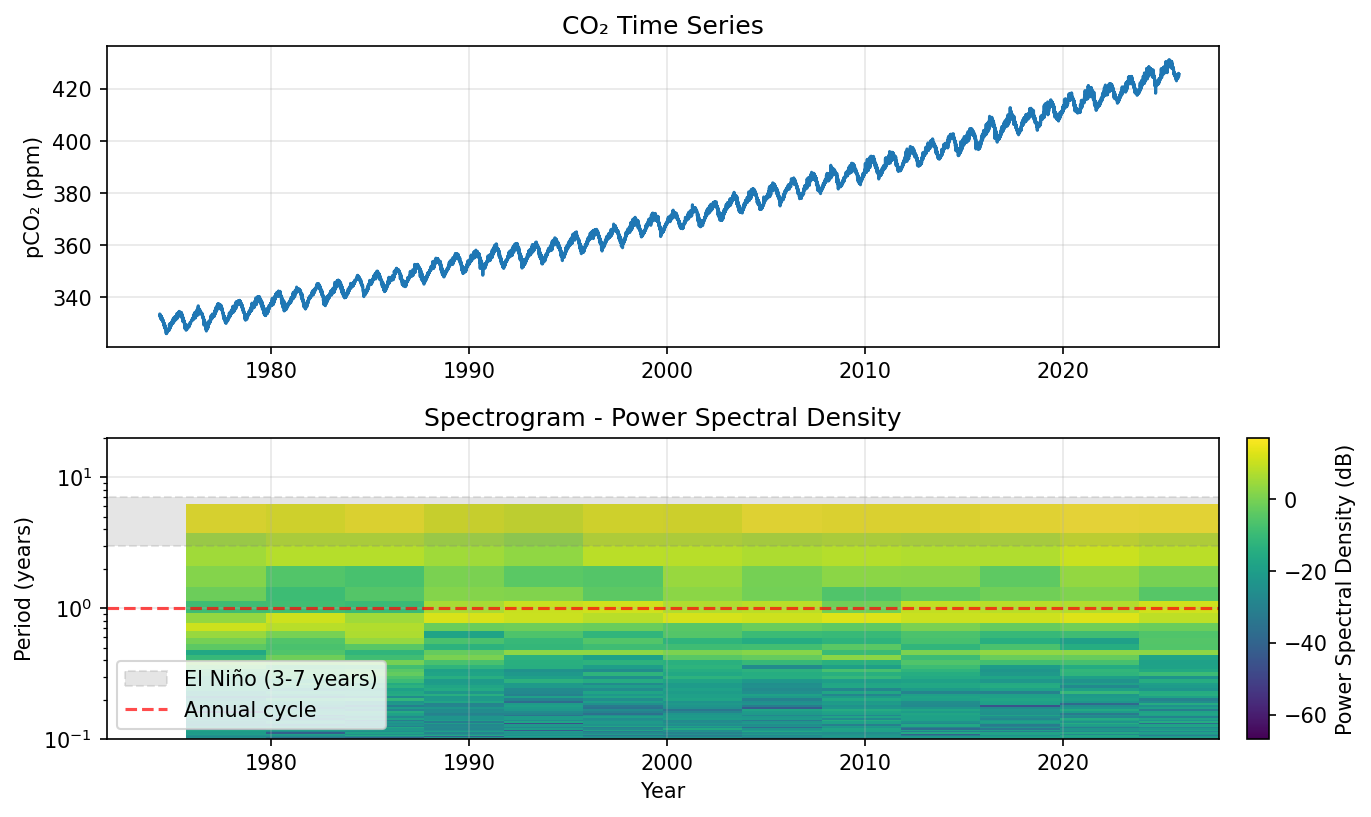

In [35]:
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Remove NaN values for spectral analysis
co2_clean = subset['pCO2'].dropna()
dates_clean = subset['decimal_date'].iloc[:len(co2_clean)]

# Create spectrogram
frequencies, times, Sxx = signal.spectrogram(
    co2_clean, 
    fs=365,  # sampling frequency (daily data = 365 samples/year)
    nperseg=365*5,  # 3-year segments
    noverlap=365*2,  # 2-year overlap
    scaling='density'
)

# Convert frequencies to periods - easier to understand in years
periods = 1 / frequencies[frequencies > 0]  # Remove DC component only
Sxx_periods = Sxx[frequencies > 0, :]

# Map spectrogram times to actual dates
start_date = dates_clean.iloc[0]
end_date = dates_clean.iloc[-1]
total_duration = end_date - start_date
spectrogram_dates = start_date + (times / times.max()) * total_duration

# Create the plot
fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[1, 1], 
              hspace=0.3, wspace=0.05)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[1, 1])

# Time series plot
ax1.plot(subset['decimal_date'], subset['pCO2'])
ax1.set_ylabel('pCO₂ (ppm)')
ax1.set_title('CO₂ Time Series')
ax1.grid(True, alpha=0.3)

# Spectrogram
im = ax2.pcolormesh(
    spectrogram_dates, 
    periods, 
    10 * np.log10(Sxx_periods),
    cmap='viridis'
)

ax2.set_ylabel('Period (years)')
ax2.set_xlabel('Year')
ax2.set_title('Spectrogram - Power Spectral Density')
ax2.set_yscale('log')
ax2.set_ylim([0.1, 20])
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Power Spectral Density (dB)')

# Mark important periods
ax2.axhspan(3, 7, color='grey', linestyle='--', alpha=0.2, label='El Niño (3-7 years)')
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Annual cycle')
ax2.legend()


## Trend Analysis
***

Fitting trends to environmental time series data helps in understanding long-term changes and patterns. We're going to explore this with Linear Regression.

In [25]:
from statsmodels.formula.api import ols

In [26]:
# we'll just work with the last 10 years for this regression
subset = dat[dat['year'] >= (dat['year'].max() - 10)]

# and start by centering the time variable
subset['decimal_date_centered'] = subset['decimal_date'] - subset['decimal_date'].mean()

/tmp/ipykernel_131434/4207027980.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['decimal_date_centered'] = subset['decimal_date'] - subset['decimal_date'].mean()


                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 3.612e+04
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:40:30   Log-Likelihood:                -7931.3
No. Observations:                3461   AIC:                         1.587e+04
Df Residuals:                    3459   BIC:                         1.588e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               413.58

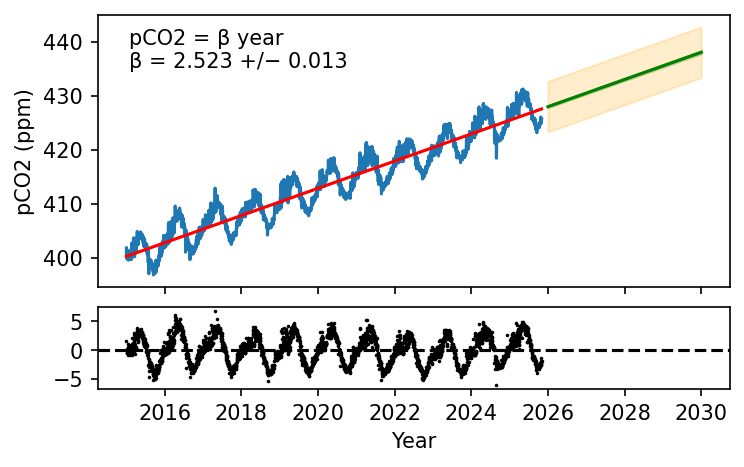

In [66]:
naive_model = ols('pCO2 ~ decimal_date_centered', data=subset).fit()
print(naive_model.summary())

model = naive_model

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.3], sharex=True, constrained_layout=True)
ax1.plot(subset['decimal_date'], subset['pCO2'])
ax1.set_ylabel('pCO2 (ppm)')
ax1.plot(subset['decimal_date'], model.fittedvalues, color='red')
ax1.text(0.05, 0.95, f'pCO2 = β year\nβ = {model.params['decimal_date_centered']:.3f} +/− {model.bse['decimal_date_centered']:.3f}', transform=ax1.transAxes, va='top')

ax2.set_xlabel('Year')
ax2.scatter(subset['decimal_date'], model.resid, color='k', s=0.5)
ax2.axhline(0, color='k', linestyle='--')

nt = np.linspace(2026, 2030, 500)
nt_centered = nt - subset['decimal_date'].mean()
preds = model.get_prediction(exog=dict(decimal_date_centered=nt_centered))

ax1.plot(nt, preds.predicted_mean, color='green')
ax1.fill_between(nt, preds.conf_int()[:, 0], preds.conf_int()[:, 1], color='green', alpha=0.3)

pred_intervals = preds.summary_frame(alpha=0.05)
ax1.fill_between(nt, pred_intervals['obs_ci_lower'], pred_intervals['obs_ci_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')


There are a number of diagnostic statistics presented alongside the regression:

**Residual distribution tests**
 - Omnibus tests for normality of residuals: If Prob(Omnibus) < 0.05, the null hypothesis of normality is rejected.
 - Jarque-Bera (JB) tests for normality of residuals: If Prob(JB) < 0.05, the null hypothesis of normality is rejected.
 - Skew: A measure of the asymmetry of the distribution of residuals. A value close to 0 indicates a symmetric distribution, while positive or negative values indicate right or left skewness, respectively.
 - Kurtosis: A measure of the "tailedness" of the distribution of residuals. A value close to 3 indicates a normal distribution, while values significantly higher or lower indicate heavy or light tails, respectively.

OLS regression assumes that the residuals are normally distributed and homoscedastic (constant variance). If these assumptions are violated, the results of the regression may not be reliable.

**Autocorrelation**
 - Durbin-Watson (DW) statistic: A measure of autocorrelation in the residuals. A value close to 2 indicates no autocorrelation, while values significantly lower than 2 indicate positive autocorrelation and values significantly higher than 2 indicate negative autocorrelation.
 - If there is significant autocorrelation in the residuals, it may indicate that the model is not adequately capturing the underlying patterns in the data.

**Multicollinearity**
 - Condition Number: A measure of multicollinearity among the independent variables. A value above 30 indicates potential multicollinearity issues, which can affect the stability and interpretability of the regression coefficients.

Based on these statistics we can see that:
 - our residuals are not normally distributed (Prob(Omnibus) < 0.05 and Prob(JB) < 0.05)
 - there is positive autocorrelation in the residuals (DW < 2)
Simple OLS regression with a linear model is not doing a good job of fitting these data!

If the assumptions of OLS regression are violated, any inferences made from the model (e.g. about trend sizes or significance) may not be valid.

The linear model above is clearly inappropriate for the data... what if we improve the model by making it more realistic? For example, we know there is a seasonal cycle in pCO2 data, so we can include seasonal terms in the model.


                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 6.177e+04
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:40:59   Log-Likelihood:                -5226.9
No. Observations:                3461   AIC:                         1.046e+04
Df Residuals:                    3457   BIC:                         1.049e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               413.53

/tmp/ipykernel_1940782/471467918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sin_annual'] = np.sin(2 * np.pi * subset['decimal_date_centered'])
/tmp/ipykernel_1940782/471467918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['cos_annual'] = np.cos(2 * np.pi * subset['decimal_date_centered'])


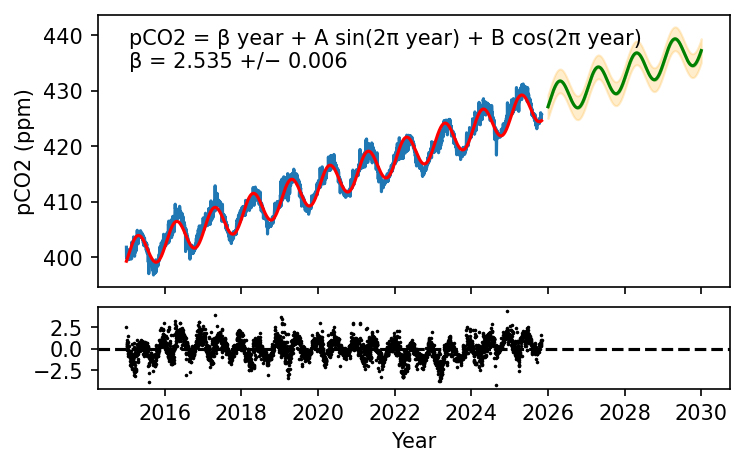

In [68]:
subset['sin_annual'] = np.sin(2 * np.pi * subset['decimal_date_centered'])
subset['cos_annual'] = np.cos(2 * np.pi * subset['decimal_date_centered'])

harmonic_model_formula = 'pCO2 ~ decimal_date_centered + sin_annual + cos_annual'
harmonic_model = ols(harmonic_model_formula, data=subset).fit()
print(harmonic_model.summary())

model = harmonic_model

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.3], sharex=True, constrained_layout=True)
ax1.plot(subset['decimal_date'], subset['pCO2'])
ax1.set_ylabel('pCO2 (ppm)')
ax1.plot(subset['decimal_date'], model.fittedvalues, color='red')
ax1.text(0.05, 0.95, f'pCO2 = β year + A sin(2π year) + B cos(2π year)\nβ = {model.params['decimal_date_centered']:.3f} +/− {model.bse['decimal_date_centered']:.3f}', transform=ax1.transAxes, va='top')

ax2.set_xlabel('Year')
ax2.scatter(subset['decimal_date'], model.resid, color='k', s=0.5)
ax2.axhline(0, color='k', linestyle='--')

nt = np.linspace(2026, 2030, 500)
nt_centered = nt - subset['decimal_date'].mean()
preds = model.get_prediction(exog=dict(decimal_date_centered=nt_centered, sin_annual=np.sin(2 * np.pi * nt_centered), cos_annual=np.cos(2 * np.pi * nt_centered)))

ax1.plot(nt, preds.predicted_mean, color='green')
ax1.fill_between(nt, preds.conf_int()[:, 0], preds.conf_int()[:, 1], color='green', alpha=0.3)

pred_intervals = preds.summary_frame(alpha=0.05)
ax1.fill_between(nt, pred_intervals['obs_ci_lower'], pred_intervals['obs_ci_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 6.261e+04
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:41:32   Log-Likelihood:                -4331.4
No. Observations:                3461   AIC:                             8675.
Df Residuals:                    3455   BIC:                             8712.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               413.53

/tmp/ipykernel_1940782/3547581948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sin_semiannual'] = np.sin(4 * np.pi * subset['decimal_date_centered'])
/tmp/ipykernel_1940782/3547581948.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['cos_semiannual'] = np.cos(4 * np.pi * subset['decimal_date_centered'])


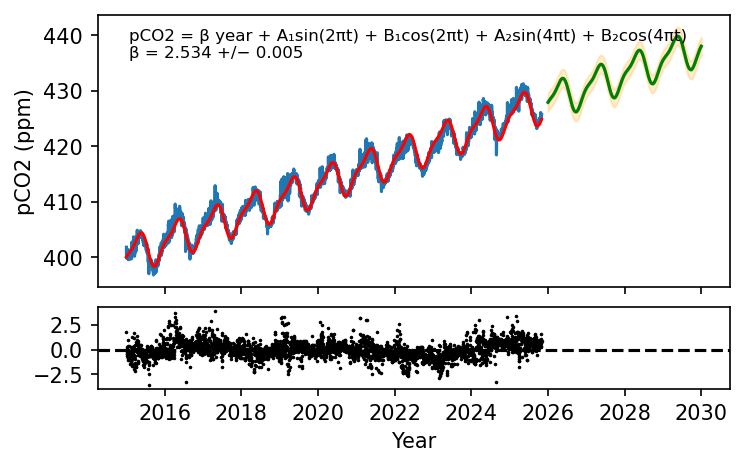

In [71]:
# Add semi-annual terms (2nd harmonic) for asymmetry
subset['sin_semiannual'] = np.sin(4 * np.pi * subset['decimal_date_centered'])
subset['cos_semiannual'] = np.cos(4 * np.pi * subset['decimal_date_centered'])

assymmetric_harmonic_model_formula = 'pCO2 ~ decimal_date_centered + sin_annual + cos_annual + sin_semiannual + cos_semiannual'

asymmetric_model = ols(assymmetric_harmonic_model_formula, data=subset).fit()
print(asymmetric_model.summary())

model = asymmetric_model

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.3], sharex=True, constrained_layout=True)
ax1.plot(subset['decimal_date'], subset['pCO2'])
ax1.set_ylabel('pCO2 (ppm)')
ax1.plot(subset['decimal_date'], model.fittedvalues, color='red')
ax1.text(0.05, 0.95, f'pCO2 = β year + A₁sin(2πt) + B₁cos(2πt) + A₂sin(4πt) + B₂cos(4πt)\nβ = {model.params["decimal_date_centered"]:.3f} +/− {model.bse["decimal_date_centered"]:.3f}', 
         transform=ax1.transAxes, va='top', fontsize=8)

ax2.set_xlabel('Year')
ax2.scatter(subset['decimal_date'], model.resid, color='k', s=0.5)
ax2.axhline(0, color='k', linestyle='--')

nt = np.linspace(2026, 2030, 500)
nt_centered = nt - subset['decimal_date'].mean()
preds = model.get_prediction(exog=dict(
    decimal_date_centered=nt_centered, 
    sin_annual=np.sin(2 * np.pi * nt_centered), 
    cos_annual=np.cos(2 * np.pi * nt_centered),
    sin_semiannual=np.sin(4 * np.pi * nt_centered),
    cos_semiannual=np.cos(4 * np.pi * nt_centered)
))

ax1.plot(nt, preds.predicted_mean, color='green')
ax1.fill_between(nt, preds.conf_int()[:, 0], preds.conf_int()[:, 1], color='green', alpha=0.3)

pred_intervals = preds.summary_frame(alpha=0.05)
ax1.fill_between(nt, pred_intervals['obs_ci_lower'], pred_intervals['obs_ci_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     2911.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:41:50   Log-Likelihood:                -4331.4
No. Observations:                3461   AIC:                             8675.
Df Residuals:                    3455   BIC:                             8712.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               413.53

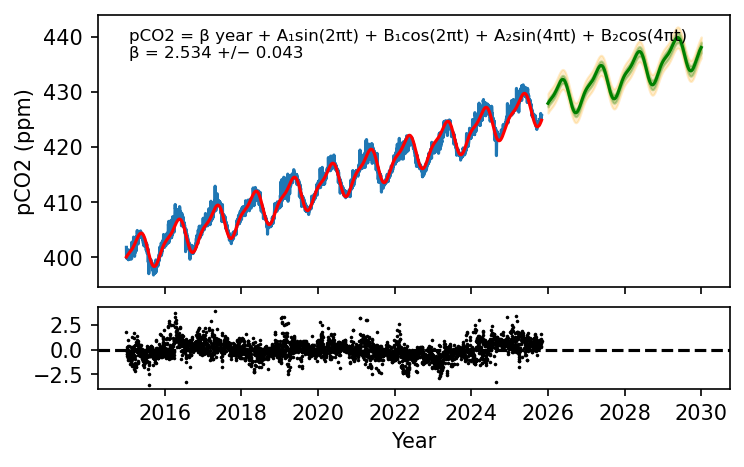

In [72]:
hac_harmonic_model = ols(assymmetric_harmonic_model_formula, data=subset).fit(cov_type='HAC', cov_kwds={'maxlags': subset.shape[0] // 4})
print(hac_harmonic_model.summary())

model = hac_harmonic_model

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.3], sharex=True, constrained_layout=True)
ax1.plot(subset['decimal_date'], subset['pCO2'])
ax1.set_ylabel('pCO2 (ppm)')
ax1.plot(subset['decimal_date'], model.fittedvalues, color='red')
ax1.text(0.05, 0.95, f'pCO2 = β year + A₁sin(2πt) + B₁cos(2πt) + A₂sin(4πt) + B₂cos(4πt)\nβ = {model.params["decimal_date_centered"]:.3f} +/− {model.bse["decimal_date_centered"]:.3f}', 
         transform=ax1.transAxes, va='top', fontsize=8)

ax2.set_xlabel('Year')
ax2.scatter(subset['decimal_date'], model.resid, color='k', s=0.5)
ax2.axhline(0, color='k', linestyle='--')

nt = np.linspace(2026, 2030, 500)
nt_centered = nt - subset['decimal_date'].mean()
preds = model.get_prediction(exog=dict(
    decimal_date_centered=nt_centered, 
    sin_annual=np.sin(2 * np.pi * nt_centered), 
    cos_annual=np.cos(2 * np.pi * nt_centered),
    sin_semiannual=np.sin(4 * np.pi * nt_centered),
    cos_semiannual=np.cos(4 * np.pi * nt_centered)
))

ax1.plot(nt, preds.predicted_mean, color='green')
ax1.fill_between(nt, preds.conf_int()[:, 0], preds.conf_int()[:, 1], color='green', alpha=0.3)

pred_intervals = preds.summary_frame(alpha=0.05)
ax1.fill_between(nt, pred_intervals['obs_ci_lower'], pred_intervals['obs_ci_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')